In [67]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

from ddpg_td3_layernorm_lunar.ddpg import DDPG
from ddpg_td3_layernorm_lunar.replay_buffer import ReplayBuffer
from ddpg_td3_layernorm_lunar.run import run_policy
from ddpg_td3_layernorm_lunar.td3 import TD3

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Most of the following code is based on https://github.com/sfujim/td3

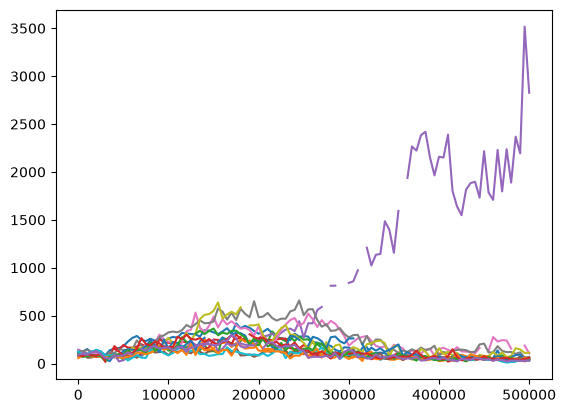

In [68]:
algo = DDPG
layer_normalization = True

for seed in range(15):
    with np.load(
        f"../results/{algo.__name__}_seed_{seed}_ln_{layer_normalization}.npz"
    ) as data:
        steps = data["steps"]
        evaluations = data["evaluations"]
        biases = data["biases"]

    plt.plot(steps, biases)

plt.show()

In [147]:
def trimmed_stats(runs, trim=0.1):
    mean = np.full(runs.shape[1], np.nan)
    std = np.full(runs.shape[1], np.nan)
    for timestep, values in enumerate(runs.T):
        values = np.sort(values[~np.isnan(values)])
        if values.size == 0:
            continue
        n_trim = int(values.size * trim)
        if n_trim > 0:
            values = values[n_trim:-n_trim]
        mean[timestep] = values.mean()
        std[timestep] = values.std()
    return mean, std


def load_and_process_data(
    results_dir: Path,
    algo: type[DDPG] | type[TD3],
    layer_normalization: bool,
    seeds: range | list,
):
    seeds = list(seeds)

    steps = []
    evaluations = []
    biases = []

    for seed in seeds:
        path = results_dir / (
            f"{algo.__name__}_seed_{seed}_ln_{layer_normalization}.npz"
        )

        with np.load(path) as data:
            steps.append(data["steps"])
            evaluations.append(data["evaluations"])
            biases.append(data["biases"])

    steps = np.stack(steps)
    evaluations = np.stack(evaluations)
    biases = np.stack(biases)

    # Make sure all runs use the same evaluation steps
    if not np.all(steps == steps[0]):
        raise ValueError("Evaluation steps differ between runs.")

    mean_evaluations, std_evaluations = trimmed_stats(evaluations, trim=0.1)
    mean_biases, std_biases = trimmed_stats(biases, trim=0.1)

    return (
        steps[0],
        mean_evaluations,
        std_evaluations,
        mean_biases,
        std_biases,
    )


results_dir = Path("../results")

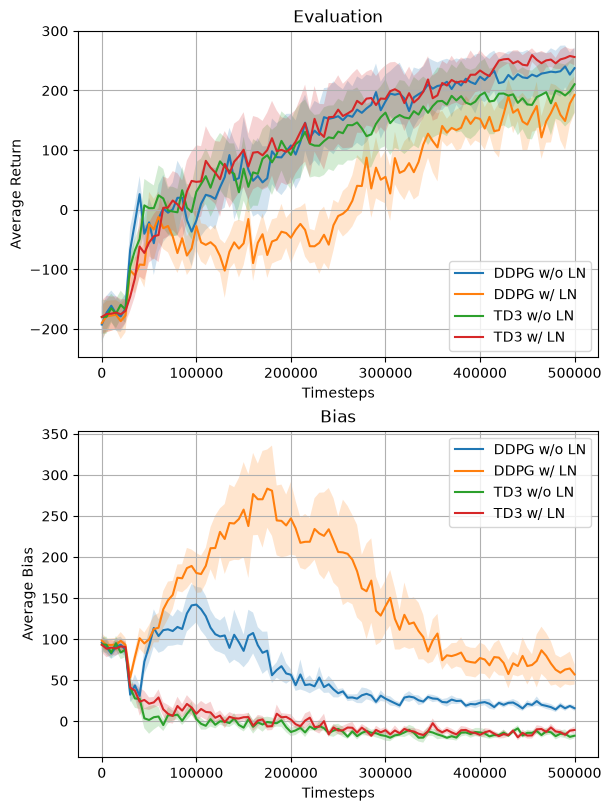

In [159]:
fig, axes = plt.subplots(2, 1, figsize=(6, 8), layout="constrained")

for algo in [DDPG, TD3]:
    for layer_normalization in [False, True]:
        # Load the runs
        steps, mean_evaluations, std_evaluations, mean_biases, std_biases = (
            load_and_process_data(
                results_dir,
                algo,
                layer_normalization,
                range(15),
            )
        )

        # Evaluation
        axes[0].set_title("Evaluation")
        axes[0].set_xlabel("Timesteps")
        axes[0].set_ylabel("Average Return")
        axes[0].plot(
            steps,
            mean_evaluations,
            label=f"{algo.__name__} {'w/' if layer_normalization else 'w/o'} LN",
        )
        axes[0].fill_between(
            steps,
            mean_evaluations - std_evaluations / 2,
            mean_evaluations + std_evaluations / 2,
            alpha=0.2,
        )
        axes[0].grid(True)
        axes[0].legend()

        # Bias
        axes[1].set_title("Bias")
        axes[1].set_xlabel("Timesteps")
        axes[1].set_ylabel("Average Bias")
        axes[1].plot(
            steps,
            mean_biases,
            label=f"{algo.__name__} {'w/' if layer_normalization else 'w/o'} LN",
        )
        axes[1].fill_between(
            steps,
            mean_biases - std_biases / 2,
            mean_biases + std_biases / 2,
            alpha=0.2,
        )
        axes[1].grid(True)
        axes[1].legend()

plt.show()

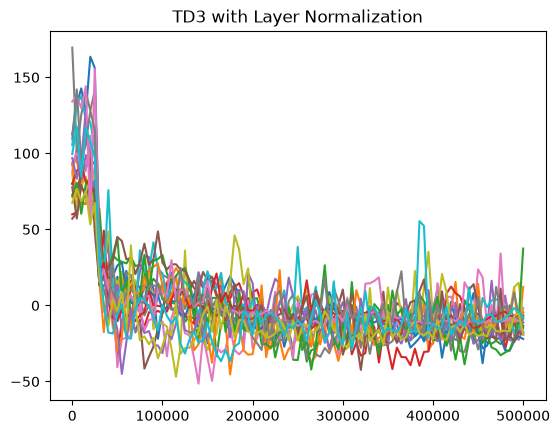

In [ ]:
plt.title(
    f"{algo.__name__} {'with' if layer_normalization else 'without'} Layer Normalization"
)
for seed in range(20):
    data = np.load(
        f"../results/{algo.__name__}_seed_{seed}_ln_{layer_normalization}.npz"
    )
    steps = data["steps"]
    evaluations = data["evaluations"]
    biases = data["biases"]

    plt.plot(steps, biases)
plt.show()

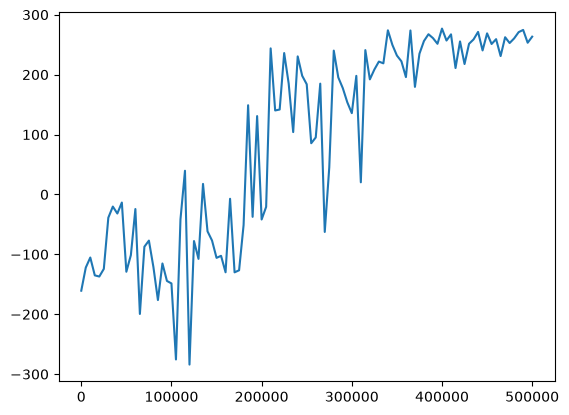

In [ ]:
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")